In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [50]:
pwd

'\\\\wsl.localhost\\Ubuntu\\home\\vineeth\\customer_churn_airflow\\CustomerChurn\\notebooks'

In [51]:
# Load the transformed data
file_path = os.path.abspath(os.path.join(os.getcwd(), "..", "data/processed/bank_churn_processed.csv"))
df = pd.read_csv(file_path)

In [58]:
# Display basic info
print("Data Shape:", df.shape)
print("Column Names:", df.columns.tolist())
print("Missing Values:")
display(df.isnull().sum())

Data Shape: (23421, 13)
Column Names: ['Customer_ID', 'Credit_Score', 'Age', 'Tenure', 'Balance', 'Num_Products', 'Has_Credit_Card', 'Is_Active', 'Salary', 'Churn', 'Country_Germany', 'Country_Spain', 'Gender_Male']
Missing Values:


Customer_ID        0
Credit_Score       0
Age                0
Tenure             0
Balance            0
Num_Products       0
Has_Credit_Card    0
Is_Active          0
Salary             0
Churn              0
Country_Germany    0
Country_Spain      0
Gender_Male        0
dtype: int64

In [59]:
# Summary statistics
print("\nSummary Statistics:")
display(df.describe())


Summary Statistics:


,Customer_ID,Credit_Score,Age,Tenure,Balance,Num_Products,Has_Credit_Card,Is_Active,Salary,Churn
count,2.342100e+04,23421.000000,23421.000000,23421.000000,23421.000000,23421.000000,23421.000000,23421.000000,23421.000000,23421.000000
mean,1.569325e+07,-0.000838,0.003941,0.003613,0.022322,-0.002206,-0.005130,0.000999,-0.003633,0.206140
std,7.219419e+04,1.008987,1.009208,1.000684,1.001762,1.002075,1.003202,0.999993,0.999092,0.404541
min,1.556570e+07,-3.624930,-2.336464,-1.791671,-1.225786,-1.008315,-1.812011,-1.030619,-2.477828,0.000000
25%,1.563285e+07,-0.741396,-0.699407,-0.725390,-0.896008,-1.008315,-1.547691,-0.994450,-0.793188,0.000000
50%,1.569151e+07,0.025568,-0.114743,-0.014537,0.239271,0.807696,0.551850,0.970194,0.072170,0.000000
75%,1.575808e+07,0.687728,0.469920,0.696317,0.948107,0.825327,0.646059,1.005538,0.847048,0.000000
max,1.581569e+07,2.523975,5.060944,1.762598,2.795184,4.492610,0.646059,1.005538,1.779529,1.000000


<Figure size 1200x800 with 0 Axes>

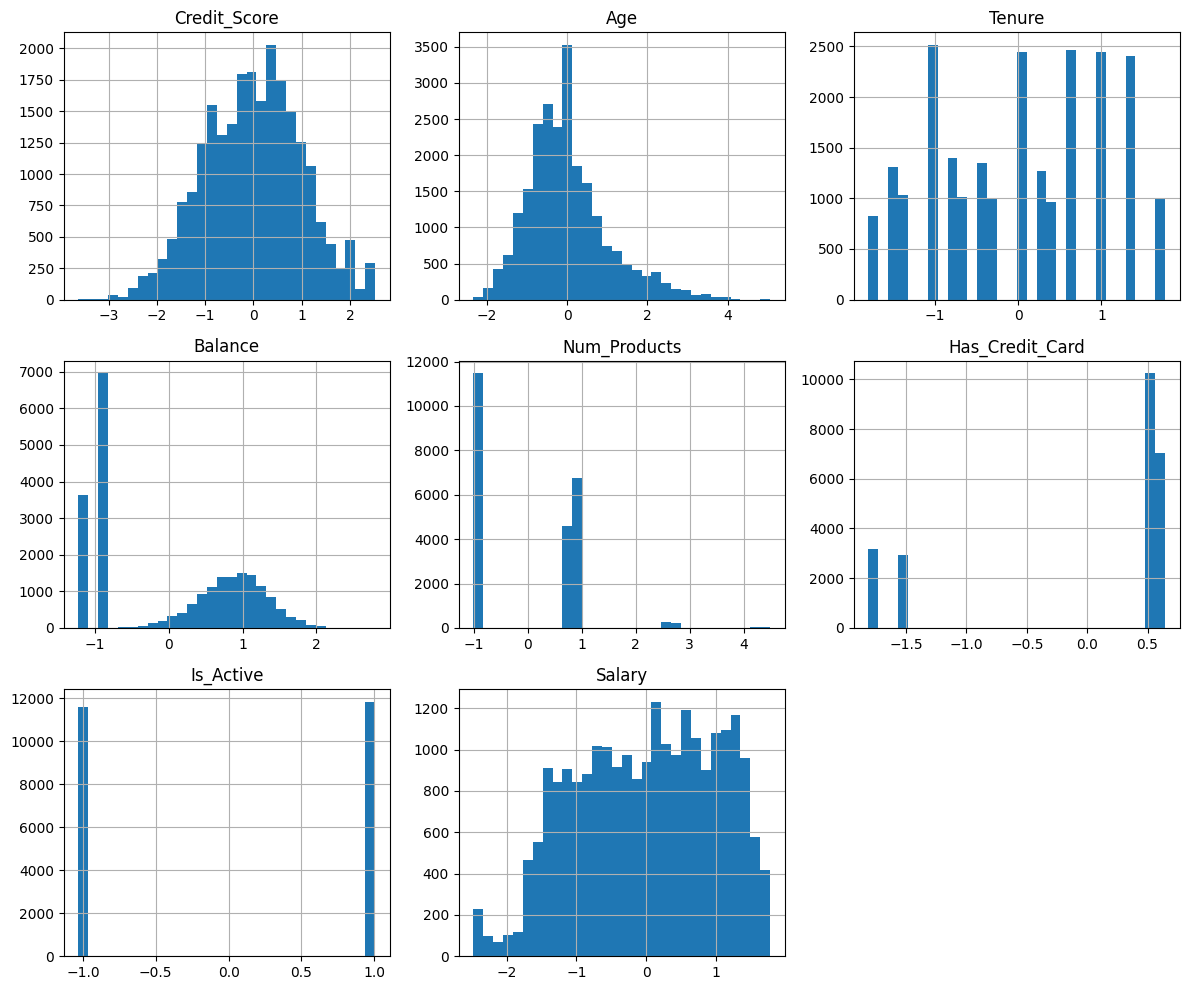

In [54]:
# Identify binary columns (having only two unique values: 0 and 1)
binary_cols = [col for col in df.select_dtypes(include=['int64', 'float64']).columns if df[col].nunique() == 2]

# Select only numerical columns, excluding 'Customer_ID' and binary attributes
numeric_cols = [col for col in df.select_dtypes(include=['float64', 'int64']).columns 
                if col != "Customer_ID" and col not in binary_cols]

# Plot the distribution of numerical features
plt.figure(figsize=(12, 8))
df[numeric_cols].hist(bins=30, figsize=(12, 10))
plt.tight_layout()
plt.show()

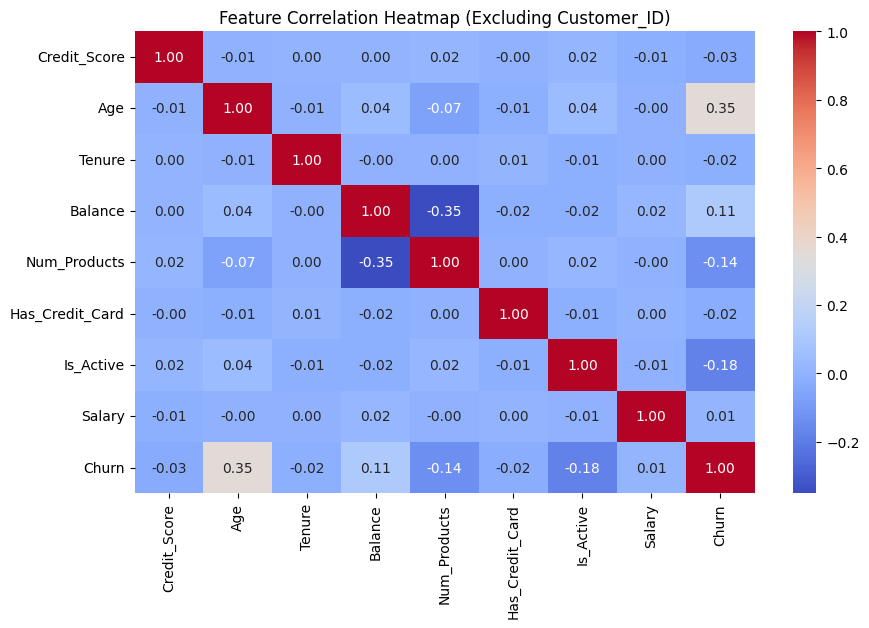

In [55]:
# Select only numeric columns and exclude 'Customer_ID'
numeric_df = df.select_dtypes(include=['number']).drop(columns=['Customer_ID'], errors='ignore')

# Plot the correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap (Excluding Customer_ID)")
plt.show()

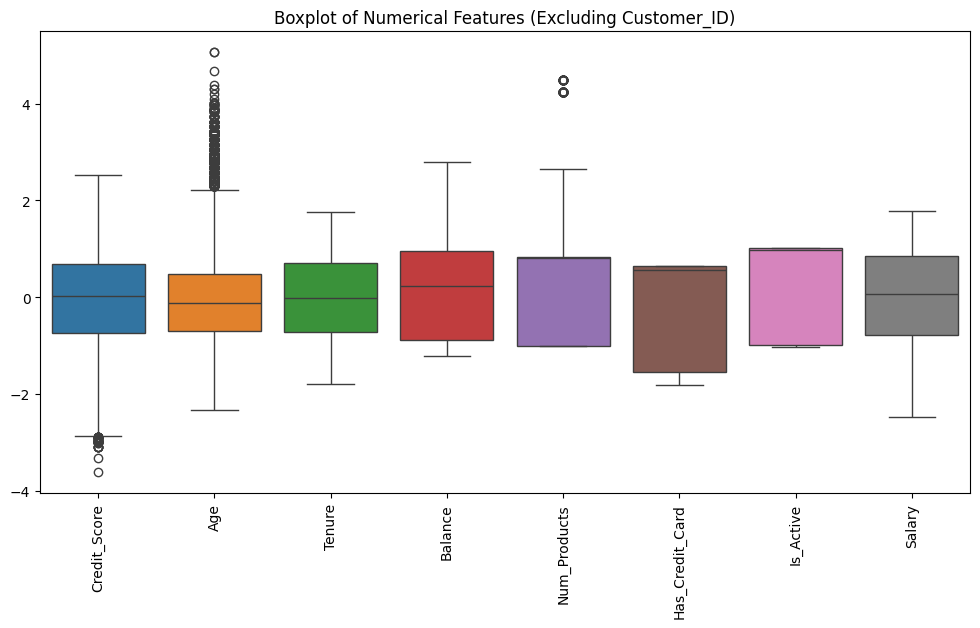

In [56]:
# Exclude 'Customer_ID' from numeric columns
numeric_cols = [col for col in numeric_cols if (col != "Customer_ID" and col != "Churn")]

# Boxplot for outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Features (Excluding Customer_ID)")
plt.show()

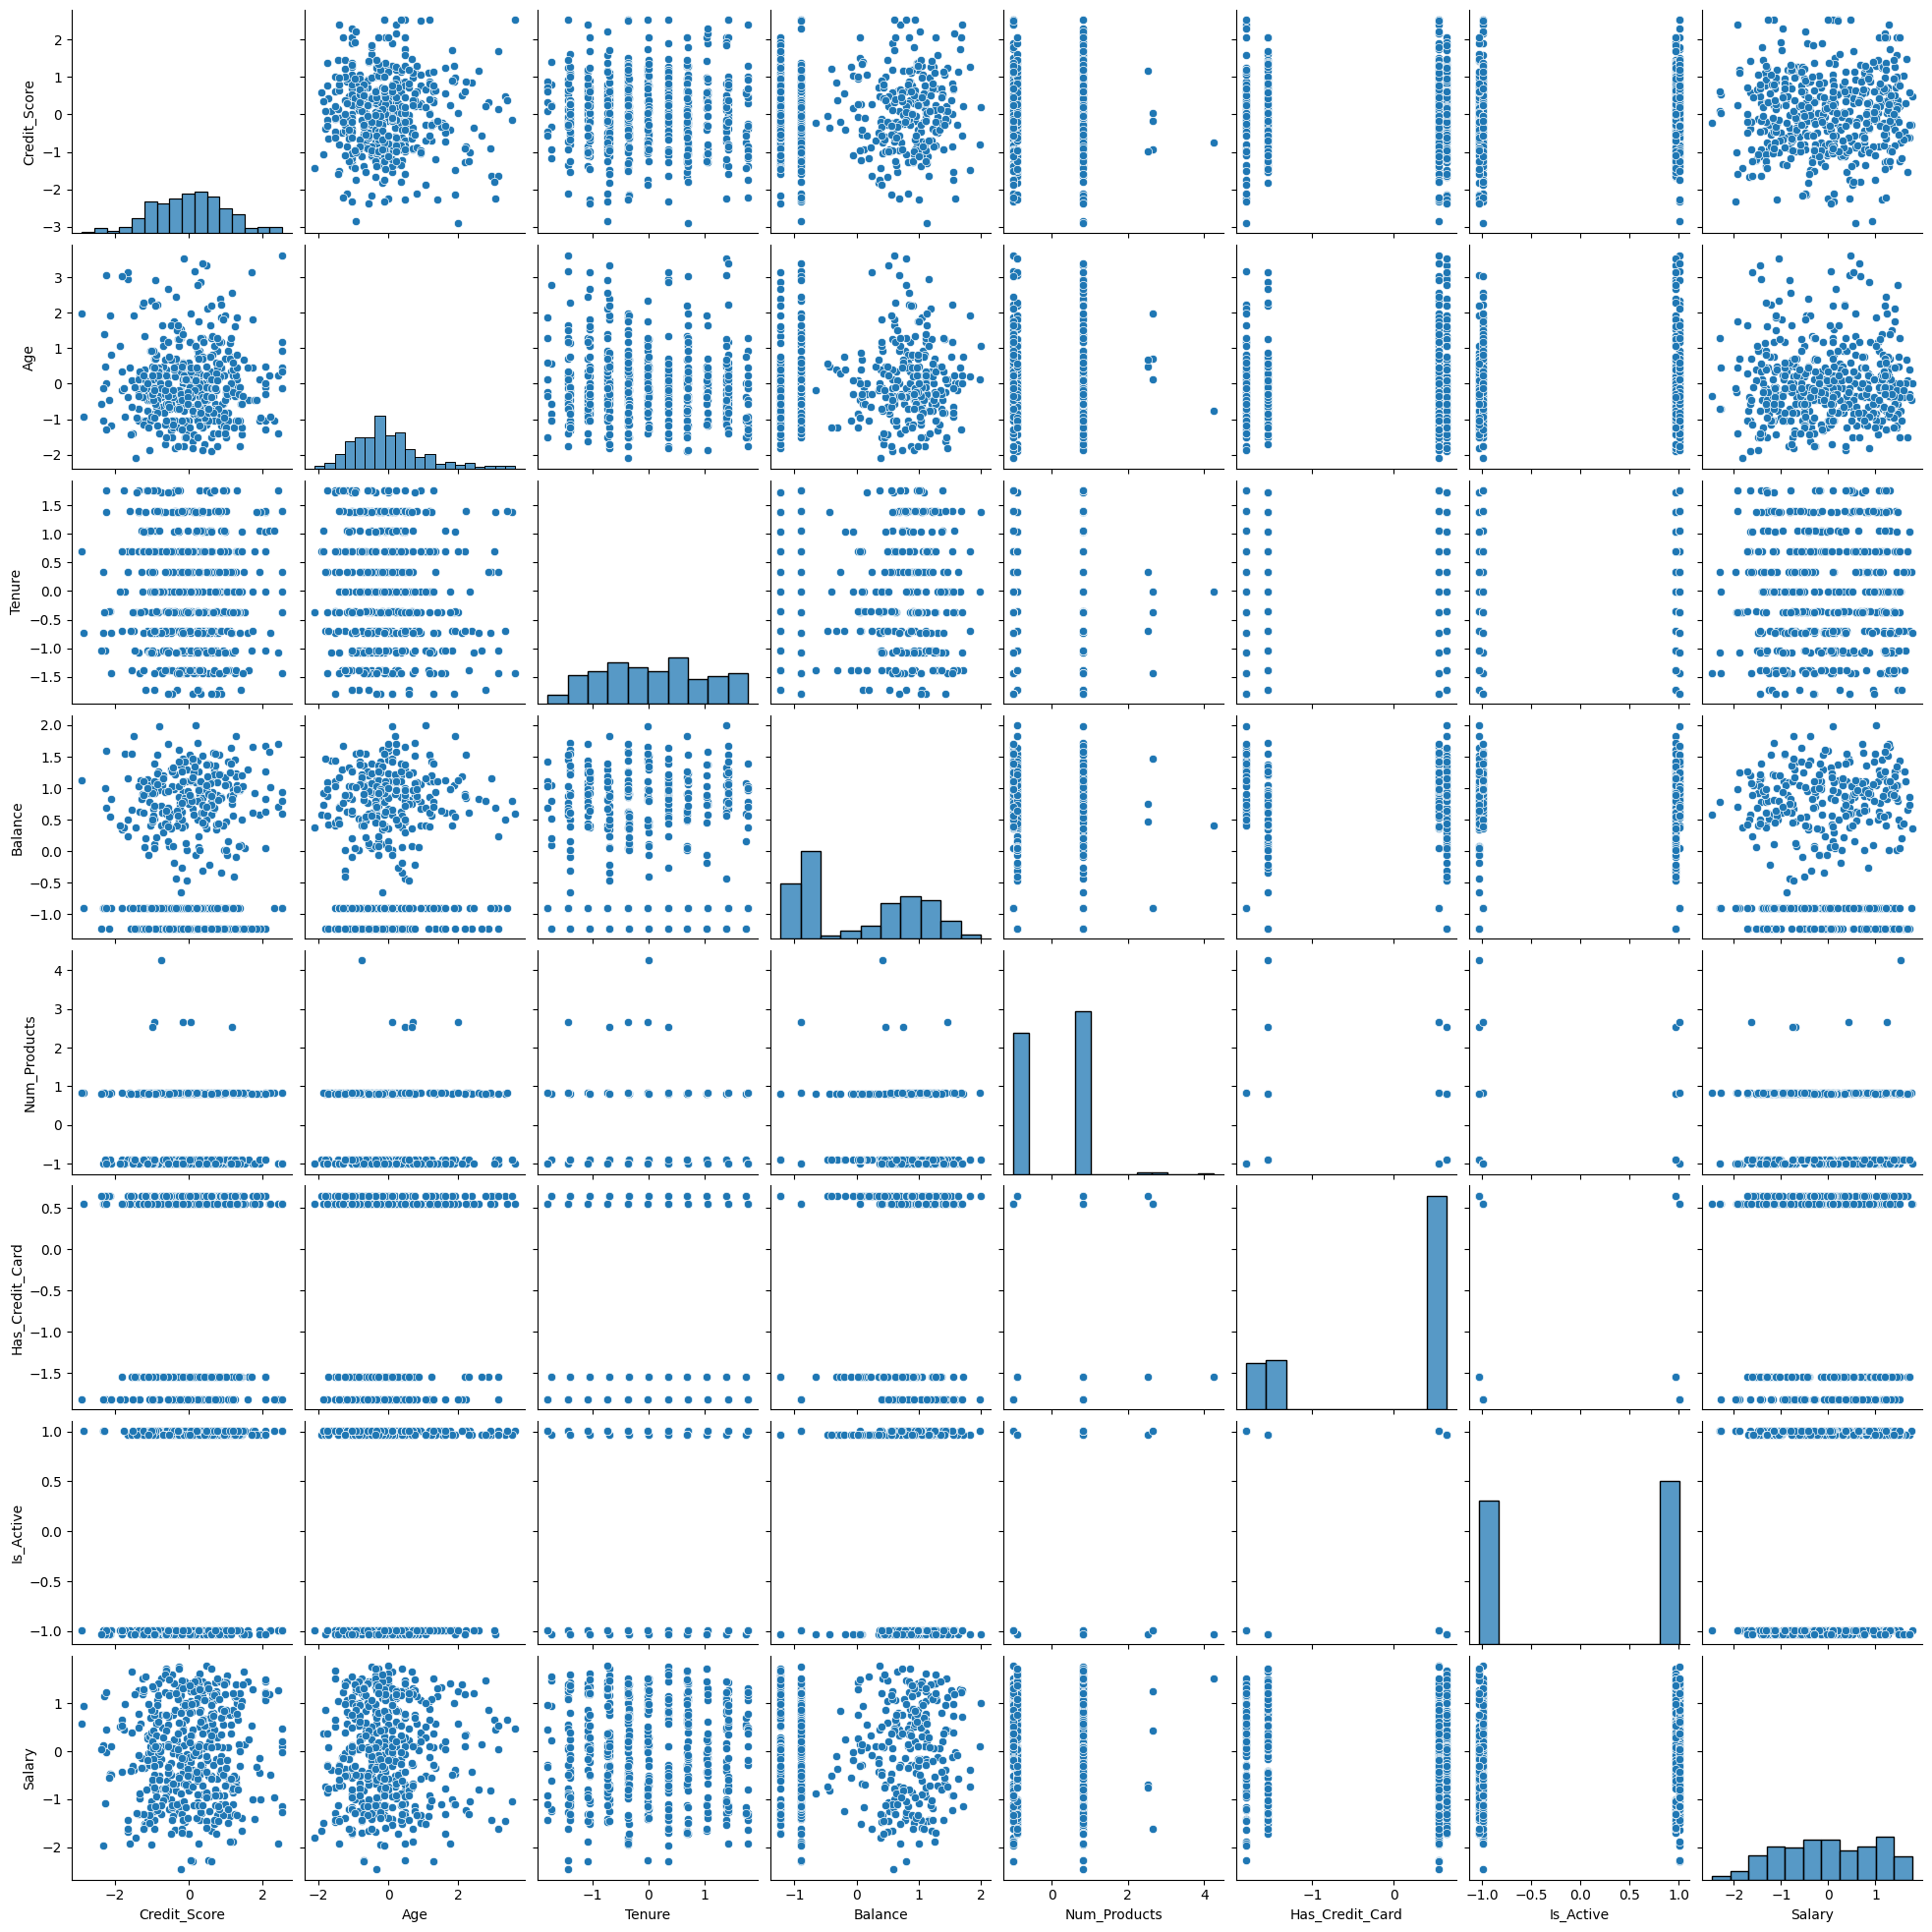

In [57]:
import warnings

with warnings.catch_warnings():
    warnings.simplefilter(action="ignore", category=FutureWarning)

    # Identify binary columns (having only two unique values: 0 and 1)
    binary_cols = [col for col in df.select_dtypes(include=['int64', 'float64']).columns if df[col].nunique() == 2]

    # Define important numerical columns (excluding Customer_ID and binary attributes)
    important_cols = [col for col in numeric_cols if col not in binary_cols and col != "Customer_ID"]

    # Sample 500 rows for performance
    sampled_df = df[important_cols].sample(min(500, len(df)), random_state=42)

    # Pairplot to check relationships
    sns.pairplot(sampled_df)
    plt.show()
